**California Housing — Python Exploratory Data Analysis (EDA) Project**


**Step 1 — Load and inspect**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df= pd.read_csv("california_housing_test.csv")

print(df.head())



   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  


In [ ]:
print("Shape :", df.shape)

Shape : (3000, 9)


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB


In [ ]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [ ]:
print("duplicates:", df.duplicated().sum())


duplicates: 0


**Step 2 — Univariate analysis**


<function matplotlib.pyplot.show(close=None, block=None)>

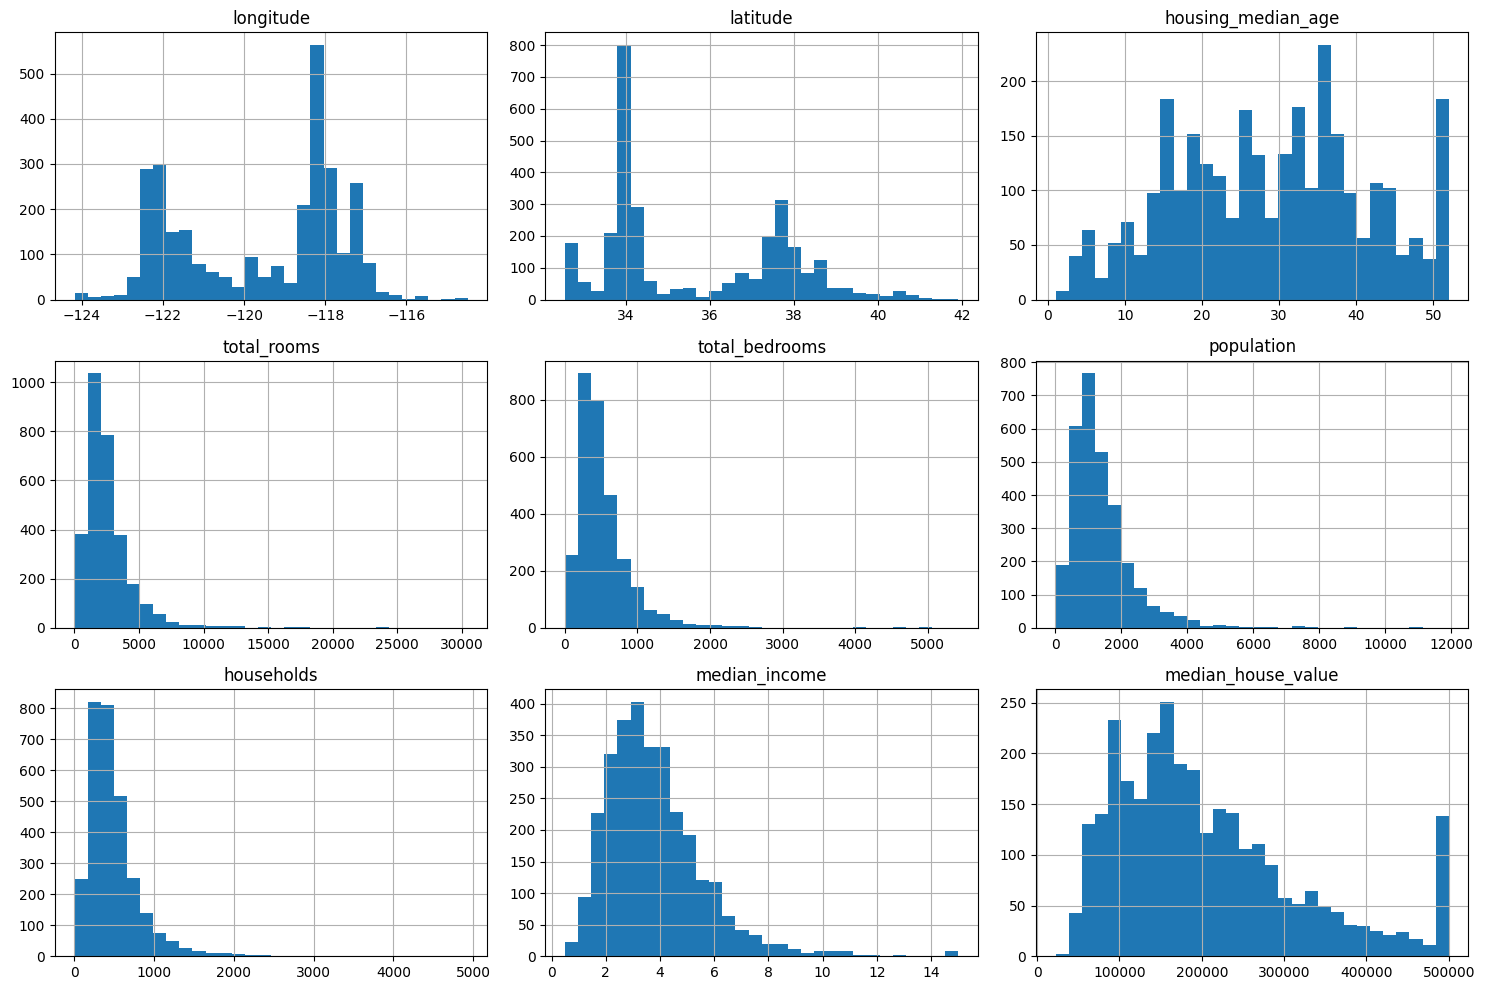

In [ ]:
df.hist(
    figsize=(15,10),
    bins=30

)
plt.tight_layout()
plt.show

**Step 3 — Boxplots for outliers**

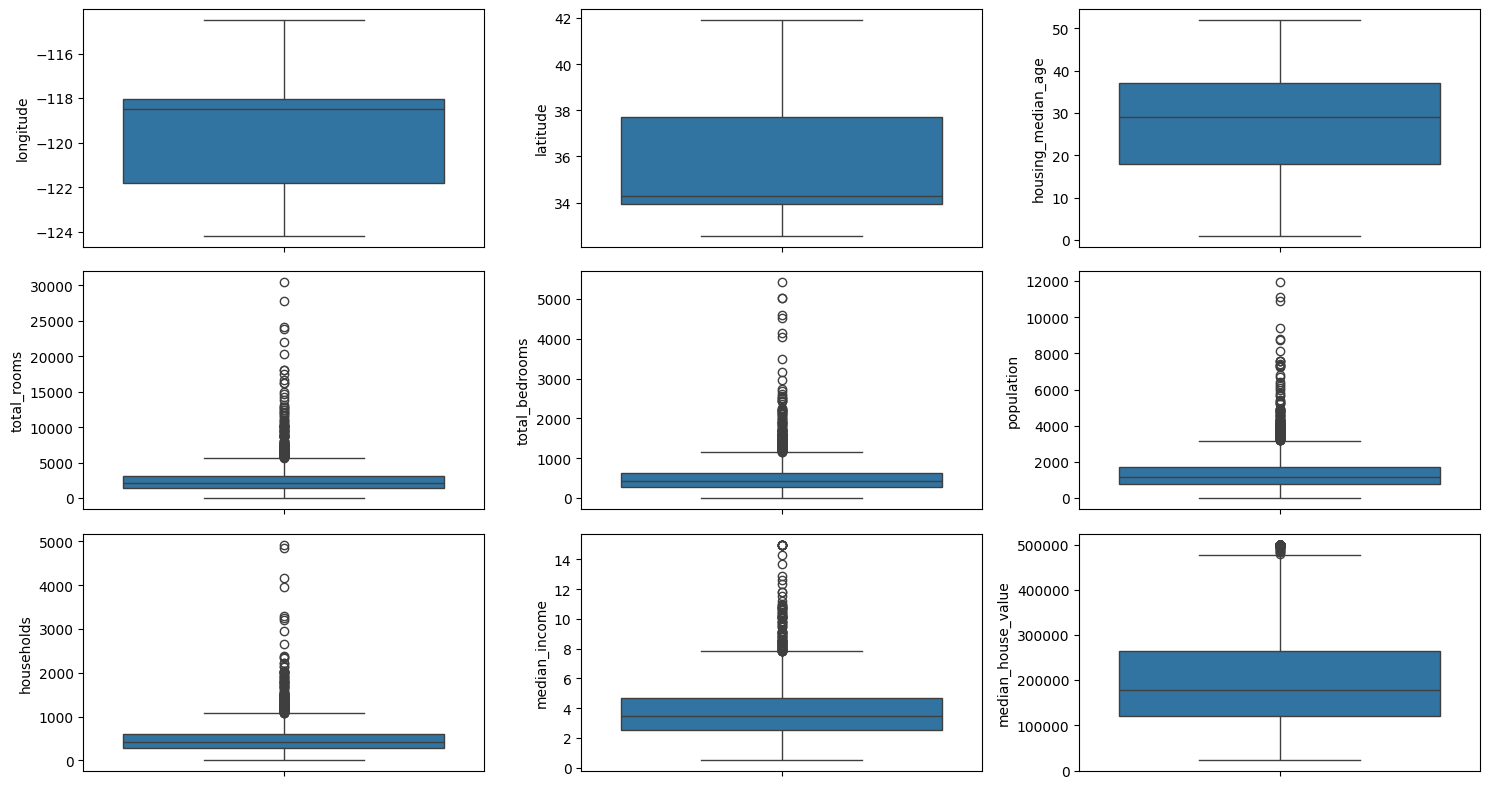

In [ ]:
plt.figure(figsize=(15,8))
for i , col in enumerate(df.columns):
  plt.subplot(3,3,i+1)
  sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

**Step 4 — Correlation matrix and heatmap**

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.925017           -0.064203     0.049865   
latitude            -0.925017  1.000000           -0.025143    -0.039632   
housing_median_age  -0.064203 -0.025143            1.000000    -0.367850   
total_rooms          0.049865 -0.039632           -0.367850     1.000000   
total_bedrooms       0.070869 -0.068245           -0.323154     0.937749   
population           0.111572 -0.117318           -0.299888     0.838867   
households           0.051062 -0.068296           -0.305171     0.914116   
median_income       -0.018701 -0.072363           -0.144315     0.221249   
median_house_value  -0.050662 -0.138428            0.091409     0.160427   

                    total_bedrooms  population  households  median_income  \
longitude                 0.070869    0.111572    0.051062      -0.018701   
latitude                 -0.068245   -0.117318   -0.068296      -0.072363   
housing_

<function matplotlib.pyplot.show(close=None, block=None)>

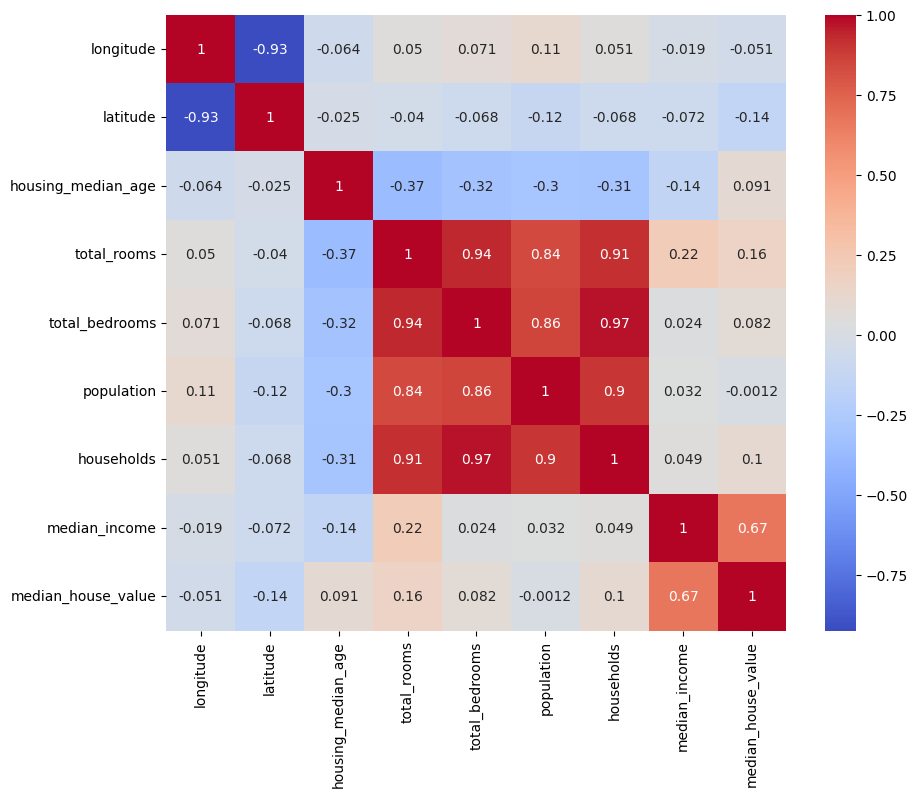

In [ ]:
corr_matrix= df.corr()
print(corr_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.show



**Step 5 — Distribution of median_income**

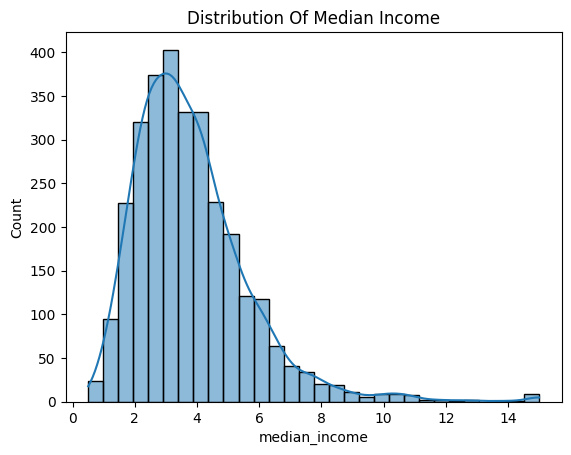

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["median_income"], bins=30 , kde =True)


plt.title("Distribution Of Median Income")
plt.show()


In [ ]:
print("Mean:", df["median_income"]. mean())
print("Median:", df["median_income"]. median())
print("Mode:", df["median_income"]. mode())

Mean: 3.8072717999999997
Median: 3.4871499999999997
Mode: 0    15.0001
Name: median_income, dtype: float64


**Step 6 — Central Limit Theorem demonstration**

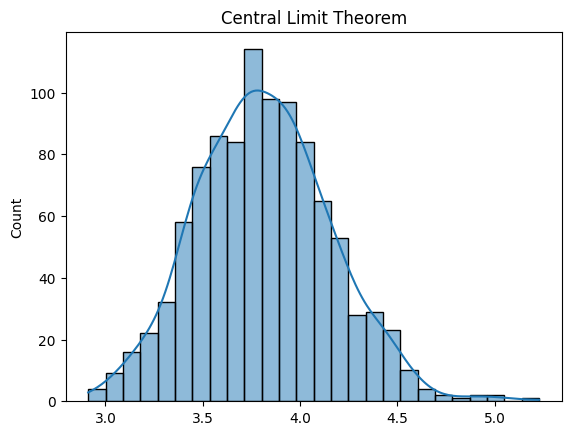

In [ ]:
import numpy as np


sample_means=[]

for i in range (1000):
  sample= df["median_income"]. sample(30)
  sample_means.append(sample.mean())

sns.histplot(sample_means, kde=True)
plt.title("Central Limit Theorem")
plt.show()



**Step 7 — Covariance and correlation between two variables**

In [ ]:
cov_matrix=df[["median_income", "median_house_value"]].cov()

print(cov_matrix)

                    median_income  median_house_value
median_income            3.439214        1.411192e+05
median_house_value  141119.191538        1.279606e+10


In [ ]:
corr=df["median_income"].corr(
    df["median_house_value"]
)
print(corr)

0.6726951532511677


**Step 8 — t-Test: high vs low income neighborhoods**

**Do High Income Neighborhoods have different house prices than low income neighborhoods ?**

In [ ]:
high = df[df["median_income"]>5]["median_house_value"]
low= df[df["median_income"]<= 5]["median_house_value"]

In [ ]:
from scipy.stats import ttest_ind

t_stat,p_value= ttest_ind(high,low)
print(t_stat)
print(p_value)

35.24865560956292
5.094317093180713e-228


Threshold p value = 0.05 ... we are getting here p value = 0.000001 , definitely p_value<0.05 - we reject Null Hypothessis


meaning - house prices difeer signinficantly beteween high and low income areas

**Step 9 — ANOVA across age groups**

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('california_housing_test.csv')
df = df.dropna()

# Use simple labels — no parentheses, no dashes
df['age_group'] = pd.cut(df['housing_median_age'],
                          bins=[0, 15, 30, 60],
                          labels=['Young', 'Middle', 'Old'])

print("Group distribution:")
print(df['age_group'].value_counts())

# Separate groups
group1 = df[df['age_group'] == 'Young']['median_house_value'].dropna()
group2 = df[df['age_group'] == 'Middle']['median_house_value'].dropna()
group3 = df[df['age_group'] == 'Old']['median_house_value'].dropna()

print(f"nYoung  — n={len(group1)}, mean=${group1.mean():,.0f}, std=${group1.std():,.0f}")
print(f"Middle — n={len(group2)}, mean=${group2.mean():,.0f}, std=${group2.std():,.0f}")
print(f"Old    — n={len(group3)}, mean=${group3.mean():,.0f}, std=${group3.std():,.0f}")

# Run ANOVA
f_stat, p_vaue = stats.f_oneway(group1, group2, group3)
print(f_stat)
print(p_value)







Group distribution:
age_group
Old       1401
Middle    1128
Young      471
Name: count, dtype: int64
nYoung  — n=471, mean=$190,481, std=$100,345
Middle — n=1128, mean=$204,759, std=$110,112
Old    — n=1401, mean=$211,887, std=$118,968
6.418261861564771
5.094317093180713e-228


**Step 10 — Chi-Square test of independence**


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency, chi2

df = pd.read_csv('california_housing_test.csv')
df['age_group'] = pd.cut(df['housing_median_age'], bins=3, labels=['New','Mid','Old'])
df['income_group'] = pd.cut(df['median_income'], bins=3, labels=['Low','Medium','High'])

table = pd.crosstab(df['age_group'], df['income_group'])
print("Observed Frequencies:\n", table)

chi2_stat, p, dof, expected = chi2_contingency(table)
print("\nExpected Frequencies:\n", pd.DataFrame(expected, index=table.index, columns=table.columns))

critical_value = chi2.ppf(0.95, dof)  # at alpha = 0.05

print(f"\nChi-Square Statistic: {chi2_stat:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"Critical Value (alpha=0.05): {critical_value:.2f}")
print(f"P-value: {p:.4f}")
print("Conclusion:", "Reject H0 - Variables are related" if p < 0.05 else "Fail to Reject H0 - Variables are independent")

Observed Frequencies:
 income_group   Low  Medium  High
age_group                       
New            590     152    12
Mid           1079     211     8
Old            855      78    15

Expected Frequencies:
 income_group          Low   Medium       High
age_group                                    
New            634.365333  110.838   8.796667
Mid           1092.050667  190.806  15.143333
Old            797.584000  139.356  11.060000

Chi-Square Statistic: 57.77
Degrees of Freedom: 4
Critical Value (alpha=0.05): 9.49
P-value: 0.0000
Conclusion: Reject H0 - Variables are related


**Step 11 — Linear Regression**


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['median_income']]          # predictor(s)
y = df['median_house_value']        # what we predict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² Score:", model.score(X_test, y_test))

Coefficient: 40940.61285055091
Intercept: 50847.821195044846
R² Score: 0.4953198289574966


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df[['median_income']]
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

beta0 = model.intercept_
beta1 = model.coef_[0]
print(f"Regression Equation: House Value = {beta0:.2f} + {beta1:.2f} * Income")

y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Predict for a new household with income = 5 (in tens of thousands)
new_income = [[5]]
predicted_value = model.predict(new_income)
print(f"Predicted House Value for income=5: {predicted_value[0]:.2f}")

Regression Equation: House Value = 50847.82 + 40940.61 * Income
R² Score: 0.495
RMSE: 79722.66
Predicted House Value for income=5: 255550.89


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df[['median_income']]
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

beta0 = model.intercept_
beta1 = model.coef_[0]
print(f"Regression Equation: House Value = {beta0:.2f} + {beta1:.2f} * Income")

y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# ---- Live demo: predict for multiple incomes at once ----
new_incomes = [2, 3000000, 5, 8000, 1000]   # ask students to suggest values
new_df = pd.DataFrame({'median_income': new_incomes})
predictions = model.predict(new_df)

for inc, pred in zip(new_incomes, predictions):
    print(f"Income = {inc} → Predicted House Value = {pred:.2f}")

Regression Equation: House Value = 50847.82 + 40940.61 * Income
R² Score: 0.495
RMSE: 79722.66
Income = 2 → Predicted House Value = 132729.05
Income = 3000000 → Predicted House Value = 122821889399.47
Income = 5 → Predicted House Value = 255550.89
Income = 8000 → Predicted House Value = 327575750.63
Income = 1000 → Predicted House Value = 40991460.67


**Step 12 — Visualising the regression line and a new prediction**

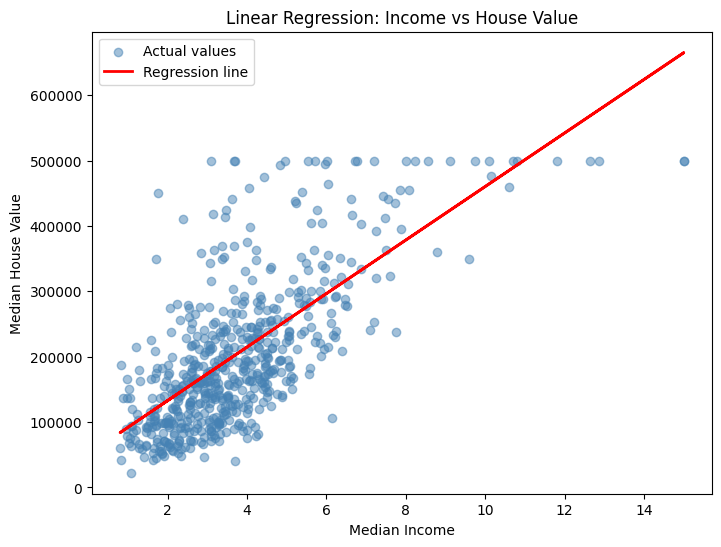

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Actual data points (test set)
plt.scatter(X_test, y_test, color='steelblue', alpha=0.5, label='Actual values')

# Regression line (predicted values)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')

plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Linear Regression: Income vs House Value')
plt.legend()
plt.show()

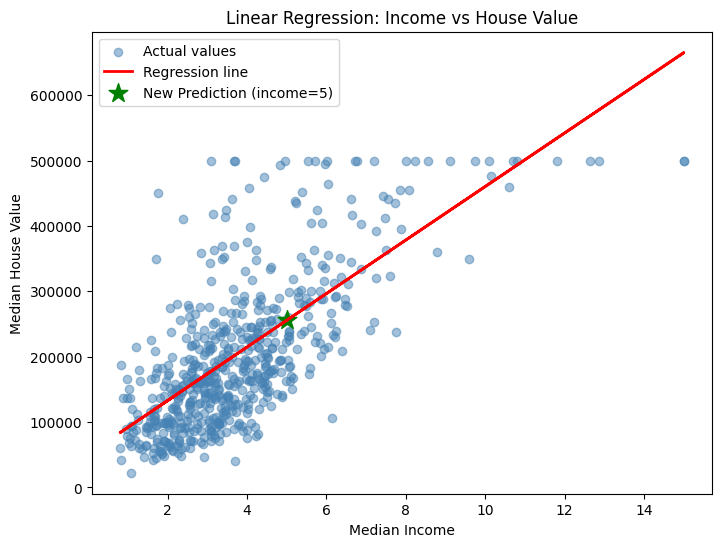

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.5, label='Actual values')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')

# Highlight the new prediction (e.g. income = 5)
new_income_val = 5
new_pred_val = model.predict(pd.DataFrame({'median_income':[new_income_val]}))[0]
plt.scatter(new_income_val, new_pred_val, color='green', s=200, marker='*',
            label=f'New Prediction (income={new_income_val})')

plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Linear Regression: Income vs House Value')
plt.legend()
plt.show()

In [ ]:
new_df = pd.DataFrame({'median_income': [30000]})
predicted_value = model.predict(new_df)[0]
print(f"Predicted House Value: ${predicted_value:,.2f}")

Predicted House Value: $1,228,269,233.34


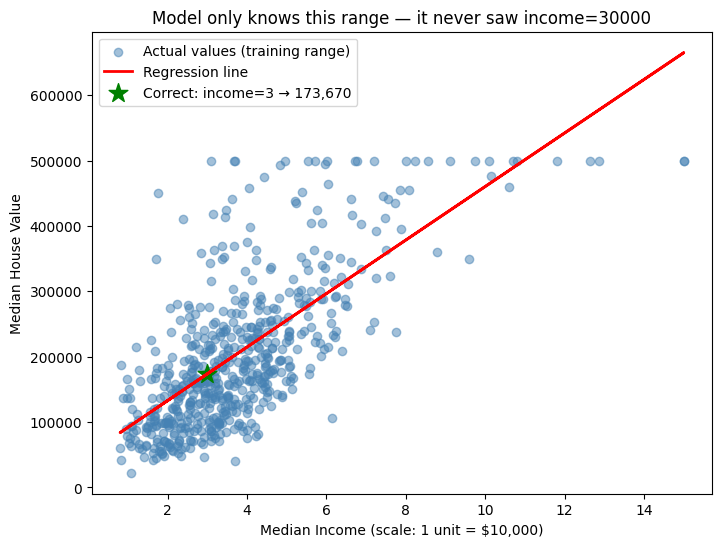

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8,6))

# Actual training data range
plt.scatter(X_test, y_test, color='steelblue', alpha=0.5, label='Actual values (training range)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')

# Correct point: income=3 (scaled)
correct_pred = model.predict(pd.DataFrame({'median_income':[3]}))[0]
plt.scatter(3, correct_pred, color='green', s=200, marker='*',
            label=f'Correct: income=3 → {correct_pred:,.0f}')

plt.xlabel('Median Income (scale: 1 unit = $10,000)')
plt.ylabel('Median House Value')
plt.title('Model only knows this range — it never saw income=30000')
plt.legend()
plt.show()

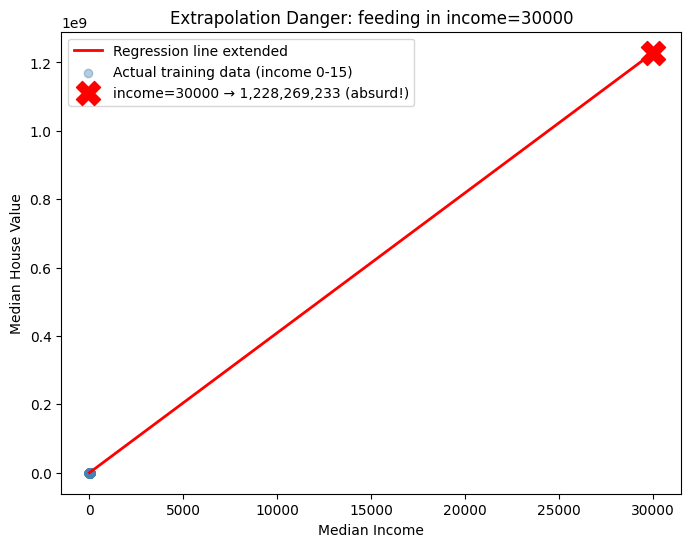

In [ ]:
import numpy as np

plt.figure(figsize=(8,6))

# Generate a wide range of income values to extrapolate the line
extreme_range = np.linspace(0, 30000, 100).reshape(-1,1)
extreme_df = pd.DataFrame({'median_income': extreme_range.flatten()})
extreme_pred = model.predict(extreme_df)

plt.plot(extreme_df, extreme_pred, color='red', linewidth=2, label='Regression line extended')
plt.scatter(X_test, y_test, color='steelblue', alpha=0.4, label='Actual training data (income 0-15)')

# Mark the wrong input
wrong_pred = model.predict(pd.DataFrame({'median_income':[30000]}))[0]
plt.scatter(30000, wrong_pred, color='red', s=300, marker='X',
            label=f'income=30000 → {wrong_pred:,.0f} (absurd!)')

plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Extrapolation Danger: feeding in income=30000')
plt.legend()
plt.show()